<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/99425_Credit_default_with_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
!pip install pycaret
from pycaret.classification import *

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv("/content/drive/MyDrive/ประสพการณ์วิชาชีพ/08_credit_default.csv")

In [ ]:
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,none,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,none,...,life insurance,40,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,none,...,car,38,none,own,1,skilled,1,none,yes,good
998,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,none,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


In [4]:
print("Checking for missing data:")
print(df.isnull().sum())

print("\nChecking for outliers (using IQR method for numerical columns):")

numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Column '{col}': {len(outliers)} potential outliers found (IQR method)")
else:
    print("No numerical columns found to check for outliers.")

print("\nDescriptive statistics for numerical columns (for general overview of distribution and potential extreme values):")
print(df.describe())

Checking for missing data:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

Checking for outliers (using IQR method for numerical columns):
Column 'duration': 70 potential outliers found (IQR method)
Column 'credit_amount': 72 potential outliers found (IQR method)
Column 'installment_commitment': 0 potential outliers found (IQR method)
Column 'residence_since': 0 potential outliers found (IQR method)
Column 'age': 23 potential outliers found (

In [5]:
df[['sex', 'status']] = df['personal_status'].str.split(' ', expand=True)
df = df.drop(columns=['personal_status'])

print("DataFrame after splitting 'personal_status' column:")
print(df.head())

DataFrame after splitting 'personal_status' column:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment other_parties  residence_since  ...  \
0                       4          none                4  ...   
1                 

In [6]:
cols = df.columns.tolist()

# Remove 'sex' and 'status' from their current positions
if 'sex' in cols:
    cols.remove('sex')
if 'status' in cols:
    cols.remove('status')

# Insert 'sex' at index 8 (9th column)
cols.insert(8, 'sex')

# Insert 'status' at index 9 (10th column)
cols.insert(9, 'status')

# Reindex the DataFrame with the new column order
df = df[cols]

print("DataFrame after reordering 'sex' and 'status' columns:")
print(df.head())

DataFrame after reordering 'sex' and 'status' columns:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     sex       status  ... property_magnitude  age  \
0                       4    male       single  ...        real es

In [7]:
# Encode categorical columns according to the mapping table

encoding_map = {

    "checking_status": {
        "<0": 0,
        "0<=X<200": 1,
        ">=200": 2,
        "no checking": 3
    },

    "credit_history": {
        "critical/other existing credit": 0,
        "existing paid": 1,
        "delayed previously": 2,
        "no credits/all paid": 3,
        "all paid": 4
    },

    "purpose": {
        "radio/tv": 0,
        "domestic appliance": 1,
        "repairs": 2,
        "retraining": 3,
        "education": 4,
        "furniture/equipment": 5,
        "used car": 6,
        "new car": 7,
        "business": 8,
        "other": 9
    },

    "savings_status": {
        "no known savings": 0,
        "<100": 1,
        "100<=X<500": 2,
        "500<=X<1000": 3,
        ">=1000": 4
    },

    "employment": {
        "unemployed": 0,
        "<1": 1,
        "1<=X<4": 2,
        "4<=X<7": 3,
        ">=7": 4
    },

    "sex": {
        "female": 0,
        "male": 1
    },

    "status": {
        "single": 0,
        "mar/wid": 1,
        "div/dep/mar": 2,
        "div/sep": 3
    },

    "other_parties": {
        "none": 0,
        "guarantor": 1,
        "co applicant": 2
    },

    "property_magnitude": {
        "no known property": 0,
        "life insurance": 1,
        "car": 2,
        "real estate": 3
    },

    "other_payment_plans": {
        "none": 0,
        "bank": 1,
        "stores": 2
    },

    "housing": {
        "for free": 0,
        "rent": 1,
        "own": 2
    },

    "job": {
        "skilled": 0,
        "unskilled resident": 1,
        "high qualif/self emp/mgmt": 2,
        "unemp/unskilled non res": 3
    },

    "own_telephone": {
        "none": 0,
        "yes": 1
    },

    "foreign_worker": {
        "no": 0,
        "yes": 1
    },

    "class": {
        "bad": 0,
        "good": 1
    }
}


# Apply encoding to the SAME columns
for col, mapping in encoding_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)


# Check result
display(df.head())

# Check whether any values failed to map
print(df[list(encoding_map.keys())].isna().sum())

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,sex,status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,0,6,0,0,1169,0,4,4,1,0,...,3,67,0,2,2,0,1,1,1,1
1,1,48,1,0,5951,1,2,2,0,2,...,3,22,0,2,1,0,1,0,1,0
2,3,12,0,4,2096,1,3,2,1,0,...,3,49,0,2,1,1,2,0,1,1
3,0,42,1,5,7882,1,3,2,1,0,...,1,45,0,0,1,0,2,0,1,1
4,0,24,2,7,4870,1,2,3,1,0,...,0,53,0,0,2,0,2,0,1,0


checking_status        0
credit_history         0
purpose                0
savings_status         0
employment             0
sex                    0
status                 0
other_parties          0
property_magnitude     0
other_payment_plans    0
housing                0
job                    0
own_telephone          0
foreign_worker         0
class                  0
dtype: int64


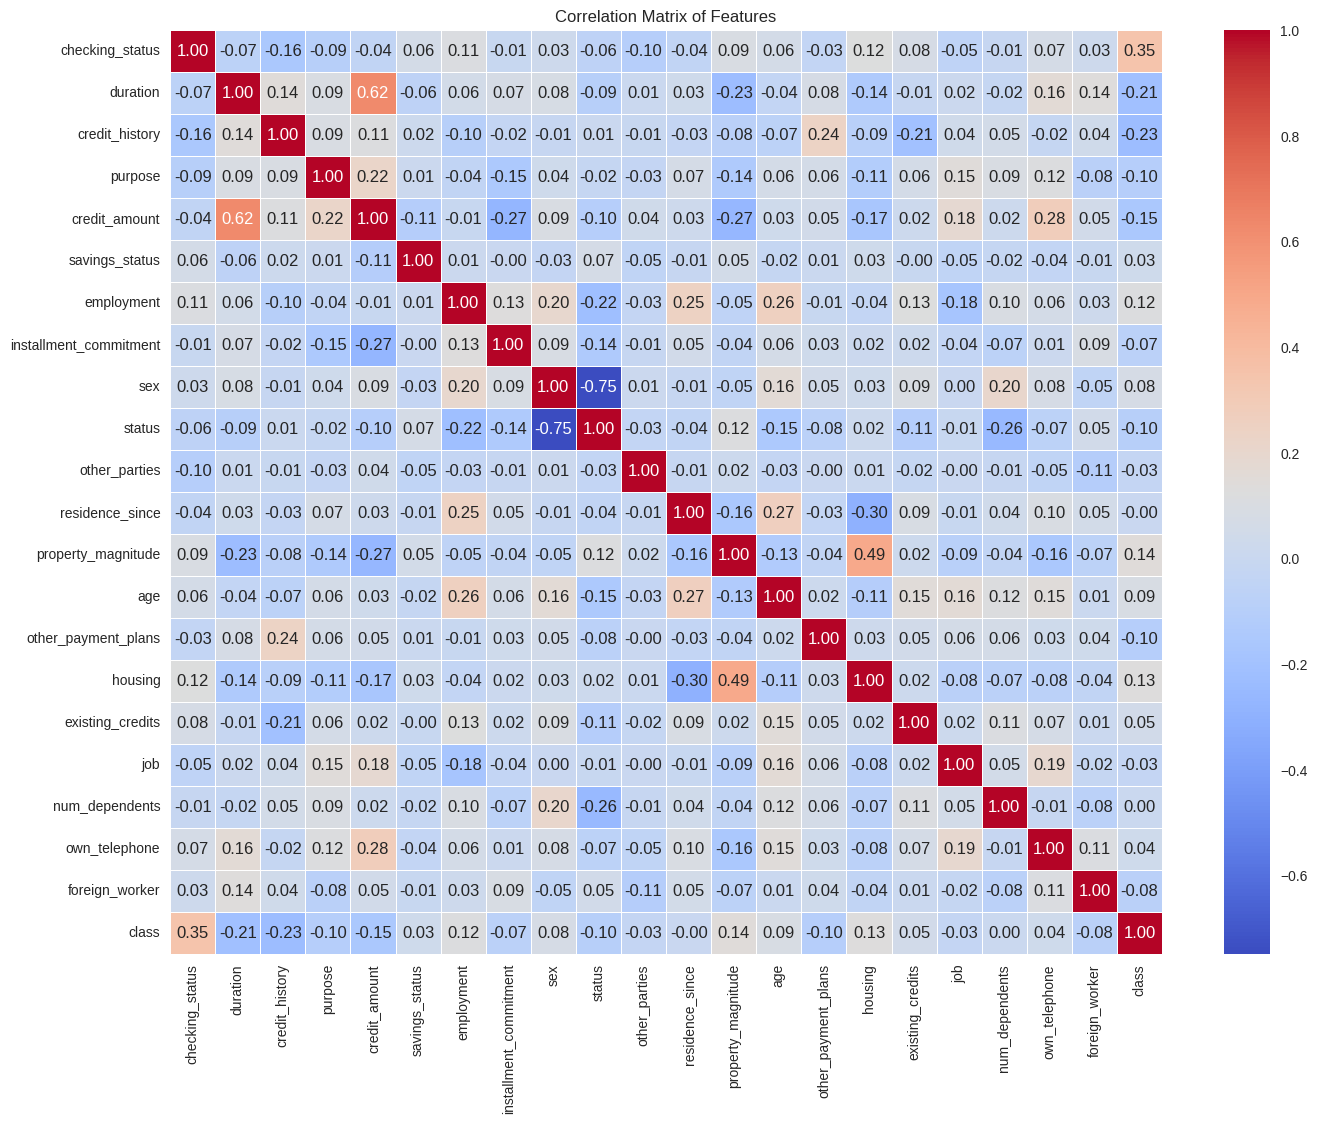

In [8]:
correlation_matrix = df.corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Columns to be scaled
columns_to_scale = ['credit_amount', 'age', 'duration','installment_commitment']

# Apply StandardScaler to the specified columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("DataFrame after scaling 'credit_amount' and 'age' columns:")
display(df.head())

DataFrame after scaling 'credit_amount' and 'age' columns:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,sex,status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,0,-1.236478,0,0,-0.745131,0,4,0.918477,1,0,...,3,2.766456,0,2,2,0,1,1,1,1
1,1,2.248194,1,0,0.949817,1,2,-0.870183,0,2,...,3,-1.191404,0,2,1,0,1,0,1,0
2,3,-0.738668,0,4,-0.416562,1,3,-0.870183,1,0,...,3,1.183312,0,2,1,1,2,0,1,1
3,0,1.750384,1,5,1.634247,1,3,-0.870183,1,0,...,1,0.831502,0,0,1,0,2,0,1,1
4,0,0.256953,2,7,0.566664,1,2,0.024147,1,0,...,0,1.535122,0,0,2,0,2,0,1,0


In [10]:
# Step 9: Extract features and target
X = df.drop('class', axis=1)
y = df['class']

print("Features shape:", X.shape)
X.head()

Features shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,sex,status,...,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,0,-1.236478,0,0,-0.745131,0,4,0.918477,1,0,...,4,3,2.766456,0,2,2,0,1,1,1
1,1,2.248194,1,0,0.949817,1,2,-0.870183,0,2,...,2,3,-1.191404,0,2,1,0,1,0,1
2,3,-0.738668,0,4,-0.416562,1,3,-0.870183,1,0,...,3,3,1.183312,0,2,1,1,2,0,1
3,0,1.750384,1,5,1.634247,1,3,-0.870183,1,0,...,4,1,0.831502,0,0,1,0,2,0,1
4,0,0.256953,2,7,0.566664,1,2,0.024147,1,0,...,4,0,1.535122,0,0,2,0,2,0,1


# Manual Model


🔸 Logistic Regression
Accuracy: 0.7650
F1 Score: 0.8385
Confusion Matrix:
 [[ 31  29]
 [ 18 122]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.52      0.57        60
           1       0.81      0.87      0.84       140

    accuracy                           0.77       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200


🔸 Decision Tree
Accuracy: 0.7050
F1 Score: 0.7870
Confusion Matrix:
 [[ 32  28]
 [ 31 109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.53      0.52        60
           1       0.80      0.78      0.79       140

    accuracy                           0.70       200
   macro avg       0.65      0.66      0.65       200
weighted avg       0.71      0.70      0.71       200


🔸 Random Forest
Accuracy: 0.7950
F1 Score: 0.8610
Confusion Matrix:
 [[ 32  28]
 [ 13 127]]
Classificatio

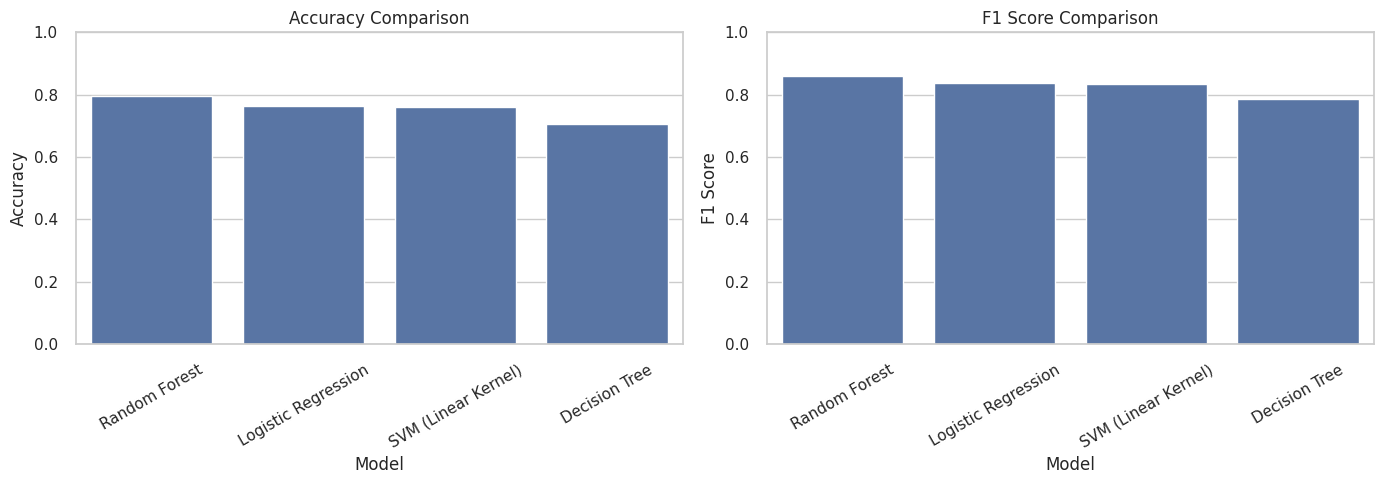

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Step 1: Split train set into training and validation subsets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Define candidate models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)
}

# Step 3: Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_split, y_train_split)
    y_pred = model.predict(X_val_split)
    acc = accuracy_score(y_val_split, y_pred)
    f1 = f1_score(y_val_split, y_pred)
    cm = confusion_matrix(y_val_split, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})

    print(f"\n🔸 {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_val_split, y_pred))

# Step 4: Display summary results
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print("\n📊 Summary of Model Performance:\n", results_df)

# สร้าง Barplots เปรียบเทียบ
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0])
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_ylim(0, 1)

sns.barplot(data=results_df, x='Model', y='F1 Score', ax=axes[1])
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [12]:
from imblearn.over_sampling import SMOTE

# ทำ SMOTE
smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=0.75)
X_train_smote, y_train_smote = smote.fit_resample(X_train_split, y_train_split)

print("Class distribution (after SMOTE):")
print(pd.Series(y_train_smote).value_counts())

# ประเมินซ้ำด้วย SMOTE Data
def evaluate_models(models, X_tr, y_tr, X_val, y_val, tag=""):
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        results.append({"Setting": tag, "Model": name, "Accuracy": acc, "F1 Score": f1})
    return pd.DataFrame(results)

smote_df = evaluate_models(models, X_train_smote, y_train_smote, X_val_split, y_val_split, tag="(SMOTE)")

combined_results_df = pd.concat([results_df.assign(Setting='Baseline'), smote_df], ignore_index=True)
combined_results_df = combined_results_df.sort_values(by=["F1 Score", "Accuracy"], ascending=False)
print("\n📊 Summary of Model Performance (Baseline vs SMOTE):\n", combined_results_df)

Class distribution (after SMOTE):
class
1    560
0    420
Name: count, dtype: int64

📊 Summary of Model Performance (Baseline vs SMOTE):
                  Model  Accuracy  F1 Score   Setting
0        Random Forest     0.795  0.861017  Baseline
1  Logistic Regression     0.765  0.838488  Baseline
2  SVM (Linear Kernel)     0.760  0.833333  Baseline
6        Random Forest     0.750  0.816176   (SMOTE)
4  Logistic Regression     0.735  0.800000   (SMOTE)
7  SVM (Linear Kernel)     0.725  0.789272   (SMOTE)
3        Decision Tree     0.705  0.787004  Baseline
5        Decision Tree     0.665  0.745247   (SMOTE)


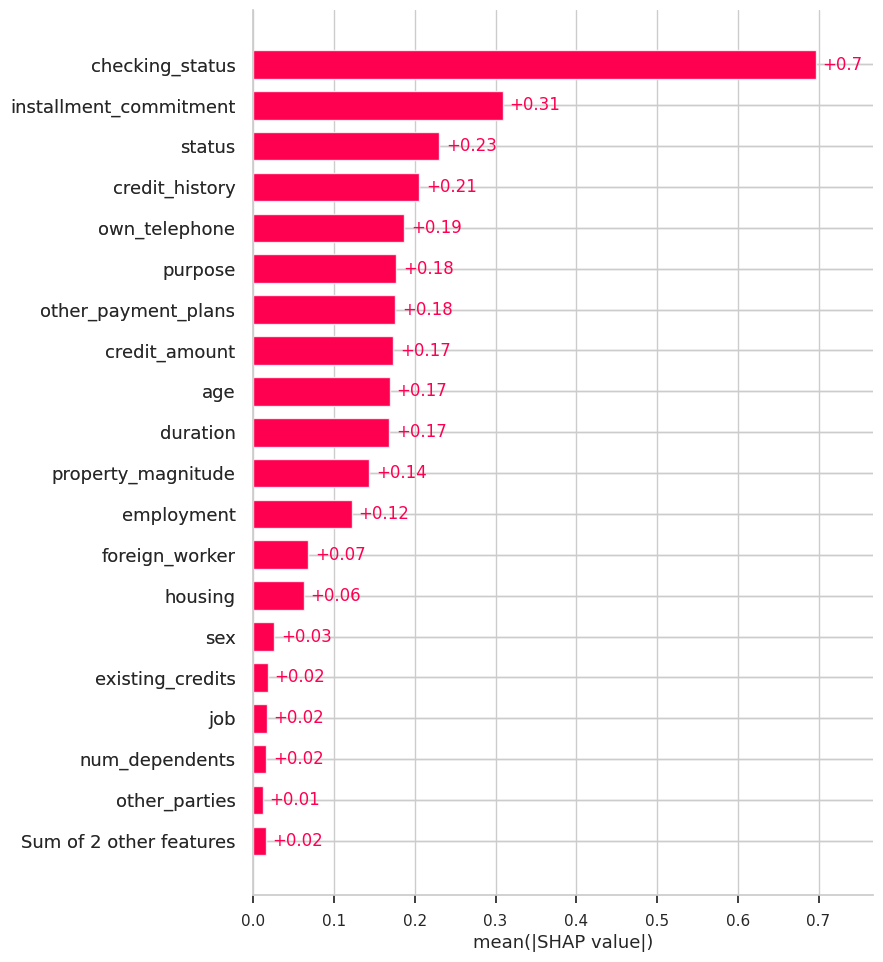

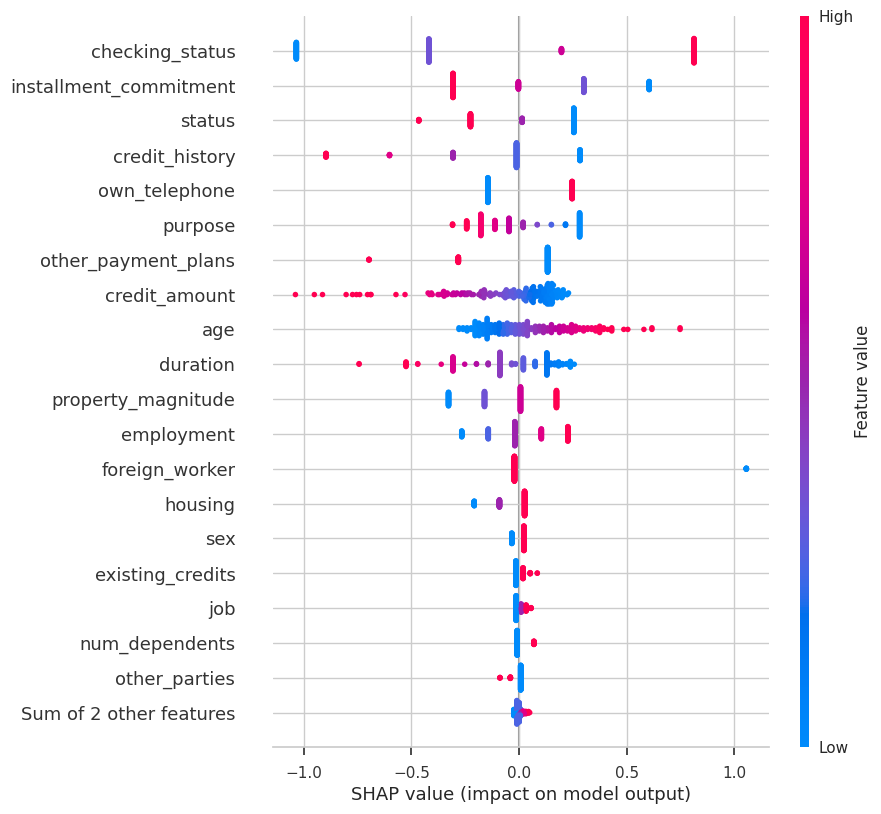

,Feature,Mean_ABS_SHAP
0,checking_status,0.696629
7,installment_commitment,0.309076
9,status,0.230424
2,credit_history,0.205502
19,own_telephone,0.187118
3,purpose,0.177187
14,other_payment_plans,0.175955
4,credit_amount,0.173126
13,age,0.168839
1,duration,0.168221


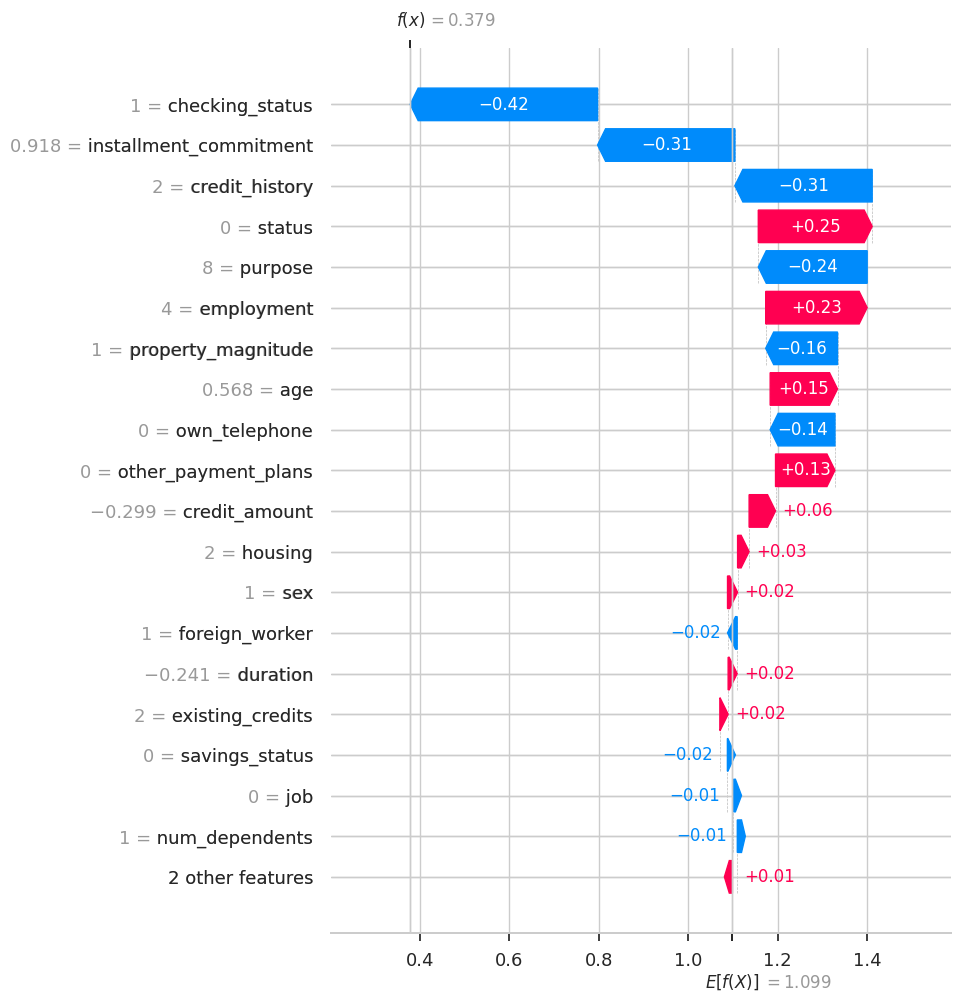

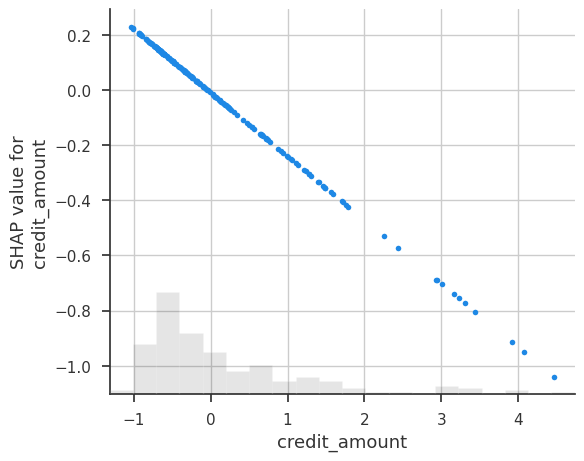

In [13]:
# =========================
# SHAP analysis for Logistic Regression
# =========================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# 1. Get Logistic Regression model
# ---------------------------------

lr_model = models["Logistic Regression"]

# If you have already run the training loop above,
# lr_model has already been fitted.
#
# Otherwise, fit it:
lr_model.fit(X_train_split, y_train_split)


# ---------------------------------
# 2. Make sure X is DataFrame
# ---------------------------------

# SHAP plots are easier to interpret when feature names are retained

if not isinstance(X_train_split, pd.DataFrame):
    X_train_split = pd.DataFrame(
        X_train_split,
        columns=X.columns
    )

if not isinstance(X_val_split, pd.DataFrame):
    X_val_split = pd.DataFrame(
        X_val_split,
        columns=X.columns
    )


# ---------------------------------
# 3. Create SHAP explainer
# ---------------------------------

# LinearExplainer is suitable for Logistic Regression

explainer = shap.LinearExplainer(
    lr_model,
    X_train_split
)

shap_values = explainer(X_val_split)


# ---------------------------------
# 4. Global feature importance
# ---------------------------------

shap.plots.bar(
    shap_values,
    max_display=20
)

plt.show()


# ---------------------------------
# 5. SHAP summary / beeswarm plot
# ---------------------------------

shap.plots.beeswarm(
    shap_values,
    max_display=20
)

plt.show()


# ---------------------------------
# 6. Feature importance as table
# ---------------------------------

shap_importance = pd.DataFrame({
    "Feature": X_val_split.columns,
    "Mean_ABS_SHAP": abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
)

display(shap_importance)


# ---------------------------------
# 7. Explain one individual patient
# ---------------------------------

patient_index = 0

shap.plots.waterfall(
    shap_values[patient_index],
    max_display=20
)

plt.show()


# ---------------------------------
# 8. Optional: dependence/scatter plot
# ---------------------------------

# Replace "credit_amount" with the feature you want to inspect

shap.plots.scatter(
    shap_values[:, "credit_amount"]
)

plt.show()

Original number of features: 21
Features to drop: ['credit_amount', 'existing_credits', 'job', 'num_dependents', 'sex', 'other_parties', 'housing', 'foreign_worker']
Reduced number of features: 13
Head of the reduced feature set (X_reduced):


,checking_status,duration,credit_history,purpose,savings_status,employment,installment_commitment,status,residence_since,property_magnitude,age,other_payment_plans,own_telephone
0,0,-1.236478,0,0,0,4,0.918477,0,4,3,2.766456,0,1
1,1,2.248194,1,0,1,2,-0.870183,2,2,3,-1.191404,0,0
2,3,-0.738668,0,4,1,3,-0.870183,0,3,3,1.183312,0,0
3,0,1.750384,1,5,1,3,-0.870183,0,4,1,0.831502,0,0
4,0,0.256953,2,7,1,2,0.024147,0,4,0,1.535122,0,0



--- Evaluating models with reduced feature set ---

🔸 Logistic Regression (Reduced Features)
Accuracy: 0.7550
F1 Score: 0.8316
Confusion Matrix:
 [[ 30  30]
 [ 19 121]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.50      0.55        60
           1       0.80      0.86      0.83       140

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.74      0.76      0.75       200


🔸 Decision Tree (Reduced Features)
Accuracy: 0.7000
F1 Score: 0.7794
Confusion Matrix:
 [[ 34  26]
 [ 34 106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.57      0.53        60
           1       0.80      0.76      0.78       140

    accuracy                           0.70       200
   macro avg       0.65      0.66      0.66       200
weighted avg       0.71      0.70      0.70       200


🔸 Random Forest

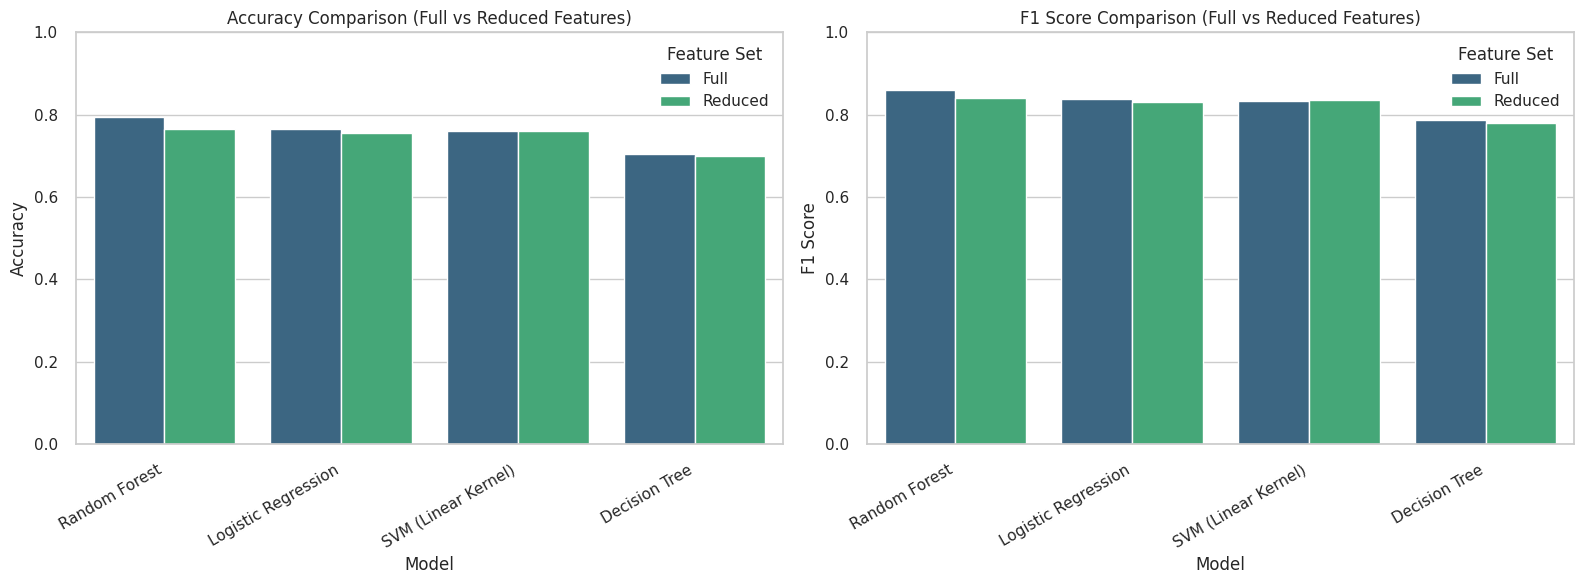

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pandas as pd

# Define the features to drop
features_to_drop = [
    'credit_amount',
    'existing_credits',
    'job',
    'num_dependents',
    'sex',
    'other_parties',
    'housing',        # Chosen as one of the lowest importance based on SHAP
    'foreign_worker'  # Chosen as one of the lowest importance based on SHAP
]

print(f"Original number of features: {X.shape[1]}")
print(f"Features to drop: {features_to_drop}")

# Create a new feature set by dropping the specified columns
X_reduced = X.drop(columns=features_to_drop)

print(f"Reduced number of features: {X_reduced.shape[1]}")
print("Head of the reduced feature set (X_reduced):")
display(X_reduced.head())

# Perform train-test split on the reduced feature set
X_train_reduced, X_val_reduced, y_train_reduced, y_val_reduced = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Evaluating models with reduced feature set ---")

# Step 2: Define candidate models (re-initialize to ensure fresh training)
models_reduced = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)
}

# Step 3: Train and evaluate each model with the reduced features
results_reduced = []

for name, model in models_reduced.items():
    model.fit(X_train_reduced, y_train_reduced)
    y_pred_reduced = model.predict(X_val_reduced)
    acc_reduced = accuracy_score(y_val_reduced, y_pred_reduced)
    f1_reduced = f1_score(y_val_reduced, y_pred_reduced)
    cm_reduced = confusion_matrix(y_val_reduced, y_pred_reduced)

    results_reduced.append({'Model': name, 'Accuracy': acc_reduced, 'F1 Score': f1_reduced})

    print(f"\n🔸 {name} (Reduced Features)")
    print(f"Accuracy: {acc_reduced:.4f}")
    print(f"F1 Score: {f1_reduced:.4f}")
    print("Confusion Matrix:\n", cm_reduced)
    print("Classification Report:\n", classification_report(y_val_reduced, y_pred_reduced))

# Step 4: Display summary results for reduced model
results_reduced_df = pd.DataFrame(results_reduced).sort_values(by='F1 Score', ascending=False)
print("\n📊 Summary of Model Performance (Reduced Features):\n", results_reduced_df)

# Optional: Compare with original full feature set results
print("\n📊 Original Model Performance (Full Features):\n", results_df)

# Plotting for comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Add a 'Feature Set' column to both dataframes for plotting
results_df_full = results_df.copy()
results_df_full['Feature Set'] = 'Full'
results_reduced_df['Feature Set'] = 'Reduced'

combined_results_for_plot = pd.concat([results_df_full, results_reduced_df], ignore_index=True)

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(data=combined_results_for_plot, x='Model', y='Accuracy', hue='Feature Set', ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy Comparison (Full vs Reduced Features)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Feature Set')

sns.barplot(data=combined_results_for_plot, x='Model', y='F1 Score', hue='Feature Set', ax=axes[1], palette='viridis')
axes[1].set_title('F1 Score Comparison (Full vs Reduced Features)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Feature Set')

plt.tight_layout()
plt.show()

--- Evaluating models with XGBoost included ---

🔸 Logistic Regression
Accuracy: 0.7650
F1 Score: 0.8385
Confusion Matrix:
 [[ 31  29]
 [ 18 122]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.52      0.57        60
           1       0.81      0.87      0.84       140

    accuracy                           0.77       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200


🔸 Decision Tree
Accuracy: 0.7050
F1 Score: 0.7870
Confusion Matrix:
 [[ 32  28]
 [ 31 109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.53      0.52        60
           1       0.80      0.78      0.79       140

    accuracy                           0.70       200
   macro avg       0.65      0.66      0.65       200
weighted avg       0.71      0.70      0.71       200


🔸 Random Forest
Accuracy: 0.7950
F1 Score: 0.8610
Confusi

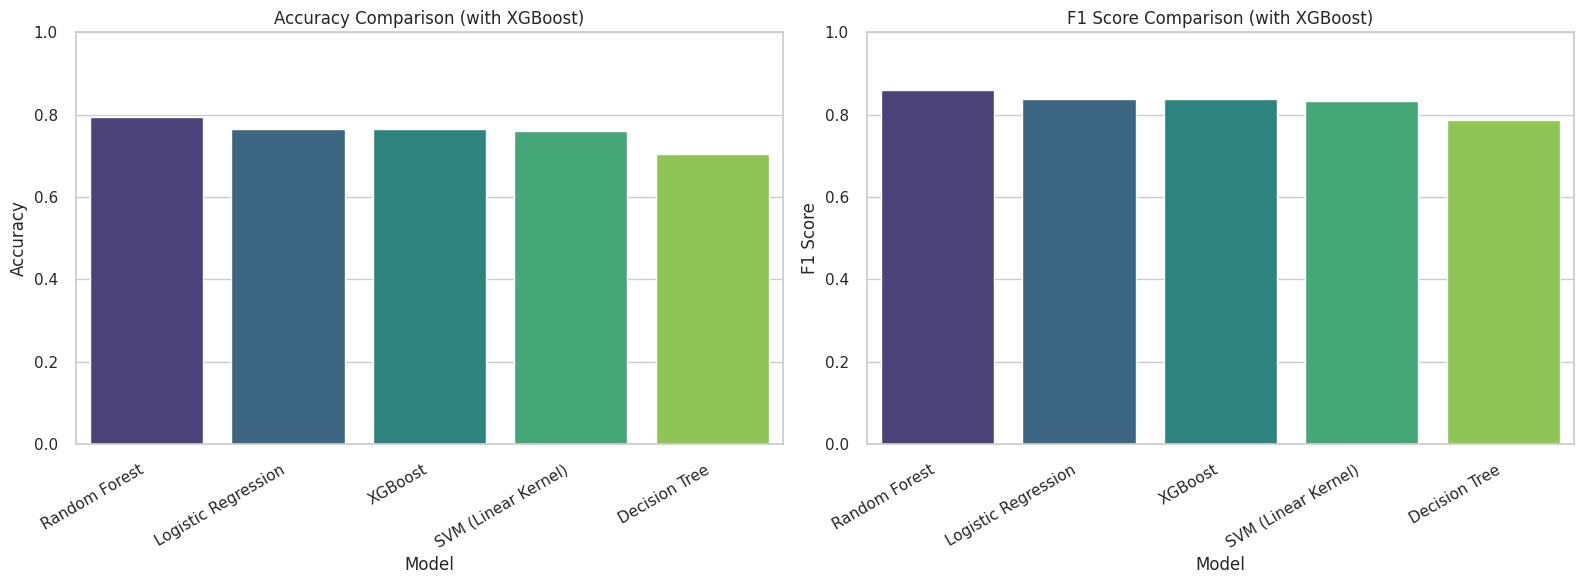

In [15]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train_split and X_val_split are DataFrames with column names for XGBoost
# The previous cell already ensures these are DataFrames, but adding a check for robustness
if not isinstance(X_train_split, pd.DataFrame):
    X_train_split = pd.DataFrame(X_train_split, columns=X.columns)
if not isinstance(X_val_split, pd.DataFrame):
    X_val_split = pd.DataFrame(X_val_split, columns=X.columns)

# Update the models dictionary to include XGBoost
models['XGBoost'] = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

print("--- Evaluating models with XGBoost included ---")

results_with_xgb = []

for name, model in models.items():
    model.fit(X_train_split, y_train_split)
    y_pred = model.predict(X_val_split)
    acc = accuracy_score(y_val_split, y_pred)
    f1 = f1_score(y_val_split, y_pred)
    cm = confusion_matrix(y_val_split, y_pred)

    results_with_xgb.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})

    print(f"\n🔸 {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_val_split, y_pred))

# Step 4: Display summary results with XGBoost
results_with_xgb_df = pd.DataFrame(results_with_xgb).sort_values(by='F1 Score', ascending=False)
print("\n📊 Summary of Model Performance (with XGBoost):\n", results_with_xgb_df)

# Plotting for comparison
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(data=results_with_xgb_df, x='Model', y='Accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy Comparison (with XGBoost)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=results_with_xgb_df, x='Model', y='F1 Score', ax=axes[1], palette='viridis')
axes[1].set_title('F1 Score Comparison (with XGBoost)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Messing with PyCaret

In [16]:
# Combine X and y สำหรับ PyCaret
df_train_full = X.copy()
df_train_full['class'] = y

# Setup PyCaret
setup(
    data=df_train_full,
    target='class',
    session_id=42,
    verbose=False,
    html=False,
    fix_imbalance=True # เปิดใช้ SMOTE อัตโนมัติ
)

# Compare models
best_model = compare_models()
print("\n✅ Best model according to PyCaret:\n", best_model)

# Tune Random Forest
rf_base = create_model('rf')
tuned_rf = tune_model(rf_base, optimize='AUC')

# Save Model
import joblib
joblib.dump(tuned_rf, 'credit_approval_model.pkl')

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.7629  0.7928  0.8429  0.8233   
xgboost         Extreme Gradient Boosting    0.7514  0.7814  0.8551  0.8030   
lightgbm  Light Gradient Boosting Machine    0.7514  0.7804  0.8531  0.8041   
rf               Random Forest Classifier    0.7414  0.7761  0.8449  0.7988   
et                 Extra Trees Classifier    0.7386  0.7632  0.8612  0.7860   
ada                  Ada Boost Classifier    0.7243  0.7439  0.7980  0.8067   
svm                   SVM - Linear Kernel    0.7043  0.7306  0.7980  0.7925   
lr                    Logistic Regression    0.7014  0.7597  0.7041  0.8458   
ridge                    Ridge Classifier    0.6943  0.7624  0.6878  0.8486   
lda          Linear Discriminant Analysis    0.6943  0.7621  0.6878  0.8486   
dt               Decision Tree Classifier    0.6800  0.6395  0.7408  0.7892   
qda       Quadratic Discriminant Analysis    0.6771 

      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7714  0.8061  0.8776  0.8113  0.8431  0.4245  0.4289
1       0.8143  0.8863  0.9388  0.8214  0.8762  0.5113  0.5300
2       0.7429  0.6939  0.8571  0.7925  0.8235  0.3525  0.3562
3       0.7000  0.7891  0.7755  0.7917  0.7835  0.2953  0.2955
4       0.8000  0.8440  0.8980  0.8302  0.8627  0.4964  0.5016
5       0.6143  0.6560  0.7959  0.6964  0.7429 -0.0150 -0.0156
6       0.7000  0.6992  0.7551  0.8043  0.7789  0.3137  0.3152
7       0.7143  0.8061  0.8571  0.7636  0.8077  0.2593  0.2659
8       0.8000  0.7799  0.8776  0.8431  0.8600  0.5105  0.5117
9       0.7571  0.8008  0.8163  0.8333  0.8247  0.4295  0.4298
Mean    0.7414  0.7761  0.8449  0.7988  0.8203  0.3578  0.3619
Std     0.0580  0.0682  0.0549  0.0408  0.0403  0.1517  0.1542


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7857  0.7833  0.8776  0.8269  0.8515  0.4681  0.4708
1       0.8571  0.8484  0.9388  0.8679  0.9020  0.6403  0.6470
2       0.7571  0.7046  0.8367  0.8200  0.8283  0.4138  0.4140
3       0.7429  0.7969  0.7755  0.8444  0.8085  0.4194  0.4229
4       0.7714  0.8115  0.8367  0.8367  0.8367  0.4558  0.4558
5       0.5714  0.6443  0.6939  0.6939  0.6939 -0.0204 -0.0204
6       0.6857  0.7085  0.7143  0.8140  0.7609  0.3082  0.3138
7       0.7429  0.8212  0.8571  0.7925  0.8235  0.3525  0.3562
8       0.7714  0.7823  0.8163  0.8511  0.8333  0.4702  0.4712
9       0.7286  0.8163  0.6939  0.8947  0.7816  0.4379  0.4631
Mean    0.7414  0.7717  0.8041  0.8242  0.8120  0.3946  0.3994
Std     0.0704  0.0613  0.0786  

['credit_approval_model.pkl']

In [17]:

# Combine X_reduced and y for PyCaret
df_train_reduce = X_reduced.copy()
df_train_reduce['class'] = y

# Setup PyCaret
setup(
    data=df_train_reduce,
    target='class',
    session_id=42,
    verbose=False,
    html=False,
    fix_imbalance=True # เปิดใช้ SMOTE อัตโนมัติ
)

# Compare models
best_model = compare_models()
print("\n✅ Best model according to PyCaret:\n", best_model)

# Tune Random Forest
rf_base = create_model('rf')
tuned_rf = tune_model(rf_base, optimize='AUC')

# Save Model
import joblib
joblib.dump(tuned_rf, 'credit_approval_model_reduce.pkl')

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.7457  0.7841  0.8143  0.8230   
et                 Extra Trees Classifier    0.7414  0.7613  0.8531  0.7933   
rf               Random Forest Classifier    0.7386  0.7634  0.8408  0.7974   
xgboost         Extreme Gradient Boosting    0.7300  0.7509  0.8224  0.7993   
lightgbm  Light Gradient Boosting Machine    0.7286  0.7451  0.8286  0.7944   
ada                  Ada Boost Classifier    0.7100  0.7559  0.7673  0.8124   
nb                            Naive Bayes    0.7043  0.7644  0.6918  0.8578   
lr                    Logistic Regression    0.7029  0.7656  0.7041  0.8484   
qda       Quadratic Discriminant Analysis    0.6957  0.7419  0.6939  0.8444   
lda          Linear Discriminant Analysis    0.6943  0.7672  0.6918  0.8448   
ridge                    Ridge Classifier    0.6929  0.7672  0.6898  0.8446   
dt               Decision Tree Classifier    0.6643 

      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7714  0.7726  0.8980  0.8000  0.8462  0.4074  0.4179
1       0.8714  0.8834  0.9796  0.8571  0.9143  0.6617  0.6858
2       0.7429  0.7046  0.8571  0.7925  0.8235  0.3525  0.3562
3       0.7286  0.7935  0.8163  0.8000  0.8081  0.3448  0.3450
4       0.6857  0.7590  0.8367  0.7455  0.7885  0.1852  0.1899
5       0.7143  0.7167  0.8367  0.7736  0.8039  0.2806  0.2835
6       0.7000  0.6822  0.7755  0.7917  0.7835  0.2953  0.2955
7       0.7429  0.8037  0.8571  0.7925  0.8235  0.3525  0.3562
8       0.7000  0.7386  0.7959  0.7800  0.7879  0.2759  0.2760
9       0.7286  0.7794  0.7551  0.8409  0.7957  0.3949  0.4000
Mean    0.7386  0.7634  0.8408  0.7974  0.8175  0.3551  0.3606
Std     0.0503  0.0549  0.0611  0.0302  0.0373  0.1195  0.1254


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7429  0.7823  0.8163  0.8163  0.8163  0.3878  0.3878
1       0.8286  0.8270  0.9388  0.8364  0.8846  0.5556  0.5698
2       0.7714  0.7240  0.8367  0.8367  0.8367  0.4558  0.4558
3       0.7143  0.8144  0.7347  0.8372  0.7826  0.3711  0.3779
4       0.7286  0.7648  0.7959  0.8125  0.8041  0.3624  0.3626
5       0.6429  0.6822  0.7551  0.7400  0.7475  0.1379  0.1380
6       0.6857  0.7104  0.7143  0.8140  0.7609  0.3082  0.3138
7       0.7571  0.8387  0.8571  0.8077  0.8317  0.3972  0.3994
8       0.7571  0.7794  0.8163  0.8333  0.8247  0.4295  0.4298
9       0.7143  0.7930  0.7143  0.8537  0.7778  0.3865  0.3987
Mean    0.7343  0.7716  0.7980  0.8188  0.8067  0.3792  0.3834
Std     0.0479  0.0491  0.0673  0.0297  0.0388  0.1018  0.1040


['credit_approval_model_reduce.pkl']

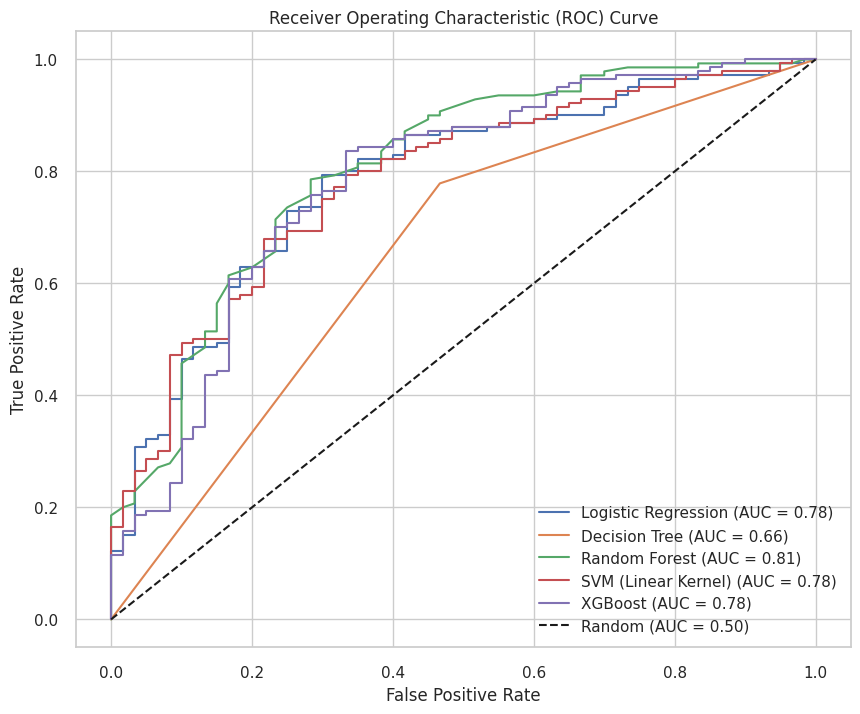

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

plt.figure(figsize=(10, 8))

# Ensure models are fitted before plotting ROC
# The 'models' dictionary already contains fitted models from the previous cells.

for name, model in models.items():
    # Some models like SVC with kernel='linear' are already fitted with probability=True
    # If not, you might need to re-fit or use predict_proba where available.
    # For SVC, we specified probability=True during initialization, so predict_proba should work.

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_val_split)[:, 1]
    elif hasattr(model, "decision_function"):
        # For SVM without probability=True, use decision_function
        y_probs = model.decision_function(X_val_split)
    else:
        print(f"Warning: Model {name} does not have predict_proba or decision_function. Skipping ROC curve.")
        continue

    fpr, tpr, thresholds = roc_curve(y_val_split, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

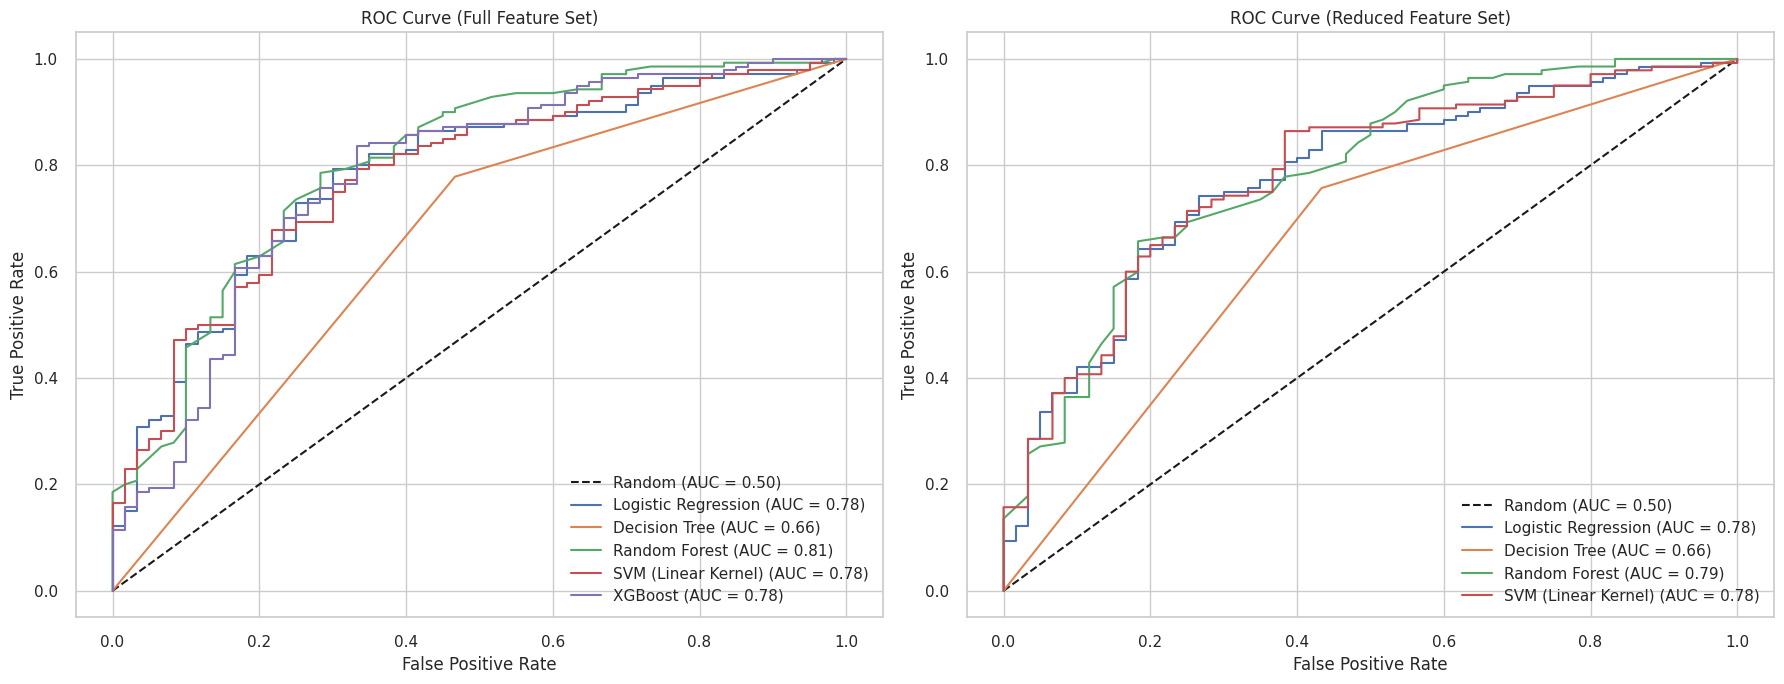

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# --- Plot ROC for Full Models ---
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_val_split)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probs = model.decision_function(X_val_split)
    else:
        print(f"Warning: Model {name} does not have predict_proba or decision_function. Skipping ROC curve for full model.")
        continue

    fpr, tpr, _ = roc_curve(y_val_split, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (Full Feature Set)')
ax1.legend(loc='lower right')
ax1.grid(True)

# --- Plot ROC for Reduced Models ---
ax2 = axes[1]
ax2.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

for name, model in models_reduced.items():
    if hasattr(model, "predict_proba"):
        y_probs_reduced = model.predict_proba(X_val_reduced)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probs_reduced = model.decision_function(X_val_reduced)
    else:
        print(f"Warning: Model {name} does not have predict_proba or decision_function. Skipping ROC curve for reduced model.")
        continue

    fpr_reduced, tpr_reduced, _ = roc_curve(y_val_reduced, y_probs_reduced)
    roc_auc_reduced = auc(fpr_reduced, tpr_reduced)
    ax2.plot(fpr_reduced, tpr_reduced, label=f'{name} (AUC = {roc_auc_reduced:.2f})')

ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve (Reduced Feature Set)')
ax2.legend(loc='lower right')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss

def evaluate_model_metrics(model, X_val, y_val, model_name, feature_set_name):
    y_pred = model.predict(X_val)

    # Get probabilities for Brier Score and AUROC
    y_prob_pos = None
    if hasattr(model, "predict_proba"):
        y_prob_pos = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        # For SVM with linear kernel, decision_function can be used as score
        y_prob_pos = model.decision_function(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    brier_score = None
    auroc = None
    if y_prob_pos is not None:
        brier_score = brier_score_loss(y_val, y_prob_pos)
        auroc = roc_auc_score(y_val, y_prob_pos)

    return {
        'Model': model_name,
        'Feature Set': feature_set_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Brier Score': brier_score,
        'AUROC': auroc
    }

all_evaluation_results = []

# Evaluate models with the FULL feature set
print("Evaluating models with Full Feature Set...")
for name, model in models.items():
    results = evaluate_model_metrics(model, X_val_split, y_val_split, name, 'Full')
    all_evaluation_results.append(results)

# Evaluate models with the REDUCED feature set
print("Evaluating models with Reduced Feature Set...")
for name, model in models_reduced.items():
    results = evaluate_model_metrics(model, X_val_reduced, y_val_reduced, name, 'Reduced')
    all_evaluation_results.append(results)

# Create a DataFrame from the results
evaluation_df = pd.DataFrame(all_evaluation_results)

# Sort by Feature Set and then by F1-Score for better readability
evaluation_df = evaluation_df.sort_values(by=['Feature Set', 'F1-Score'], ascending=[True, False])

print("\n### Model Evaluation Matrix ###")
print(evaluation_df.to_string(index=False, float_format="%.4f"))

Evaluating models with Full Feature Set...
Evaluating models with Reduced Feature Set...

### Model Evaluation Matrix ###
              Model Feature Set  Accuracy  Precision  Recall  F1-Score  Brier Score  AUROC
      Random Forest        Full    0.7950     0.8194  0.9071    0.8610       0.1581 0.8063
Logistic Regression        Full    0.7650     0.8079  0.8714    0.8385       0.1669 0.7833
            XGBoost        Full    0.7650     0.8079  0.8714    0.8385       0.1724 0.7810
SVM (Linear Kernel)        Full    0.7600     0.8108  0.8571    0.8333       0.1672 0.7819
      Decision Tree        Full    0.7050     0.7956  0.7786    0.7870       0.2950 0.6560
      Random Forest     Reduced    0.7650     0.8000  0.8857    0.8407       0.1625 0.7858
SVM (Linear Kernel)     Reduced    0.7600     0.7987  0.8786    0.8367       0.1660 0.7817
Logistic Regression     Reduced    0.7550     0.8013  0.8643    0.8316       0.1685 0.7757
      Decision Tree     Reduced    0.7000     0.8030  0.757

In [ ]:
import gradio as gr
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 0. Ensure Gradio is installed ---
!pip install -q gradio

# Assume 'encoding_map' and 'scaler' are available from the notebook's global state
# encoding_map was created in cell U2Rj1PDhJmH_
# scaler was fitted in cell i3njJLfEL4BN

# --- 1. Load the trained models ---
# These are the PyCaret tuned Random Forest models saved earlier.
model_full = joblib.load('credit_approval_model.pkl')
model_reduced = joblib.load('credit_approval_model_reduce.pkl')

# --- 2. Define the columns used for each model ---
# These must match the exact column names and order used during training (X and X_reduced)
full_model_feature_names = ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'sex', 'status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']
reduced_model_feature_names = ['checking_status', 'duration', 'credit_history', 'purpose', 'savings_status', 'employment', 'installment_commitment', 'status', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'own_telephone']

# Numerical columns that were scaled by 'scaler'
# This list must match the columns the global `scaler` was originally fitted on.
scaled_numerical_cols = ['credit_amount', 'age']

# --- 3. Helper function for preprocessing Gradio inputs ---
# This function takes raw inputs (e.g., from Gradio Textboxes/Dropdowns)
# and transforms them into the format expected by the models (encoded, scaled).
def preprocess_inputs_for_gradio(raw_inputs_dict, target_feature_names):
    # Create a DataFrame from the raw inputs, ensuring correct column order
    input_df = pd.DataFrame([raw_inputs_dict], columns=target_feature_names)

    # Apply encoding for categorical columns using the global encoding_map
    for col, mapping in encoding_map.items():
        if col in input_df.columns: # Check if column exists in the current model's features
            # Check if it's a categorical column (object type) and if it has a mapping
            if input_df[col].dtype == 'object' and col in encoding_map:
                input_df[col] = input_df[col].map(mapping)

    # Handle numerical scaling. The global `scaler` was fitted on `scaled_numerical_cols`.
    # We need to ensure that `scaler.transform` always receives a DataFrame with these columns
    # in the correct order, even if some are not part of the current model's `target_feature_names`.
    df_for_scaling = pd.DataFrame(0.0, index=input_df.index, columns=scaled_numerical_cols)

    for col in scaled_numerical_cols:
        if col in input_df.columns: # If the current model uses this scaled numerical feature
            df_for_scaling[col] = input_df[col]

    # Transform the prepared DataFrame using the global scaler
    scaled_values_full = scaler.transform(df_for_scaling)

    # Update the original input_df with the scaled values, only for features that are actually present
    for i, col in enumerate(scaled_numerical_cols):
        if col in input_df.columns:
            input_df[col] = scaled_values_full[:, i]

    # Fill any potential NaN from unmapped values (should not happen with correct inputs and comprehensive mapping)
    # Or ensure all columns are numeric, by filling potential NaNs from mapping failures (e.g., if an unexpected category is passed)
    input_df = input_df.fillna(0)

    return input_df

# --- 4. Prediction functions for Gradio ---
def predict_full_model(*raw_input_values):
    raw_inputs_dict = dict(zip(full_model_feature_names, raw_input_values))
    processed_input = preprocess_inputs_for_gradio(raw_inputs_dict, full_model_feature_names)

    prediction_proba = model_full.predict_proba(processed_input)[0]

    # Assuming 'class' map: 0 = bad, 1 = good
    if prediction_proba[1] > prediction_proba[0]:
        result = f"Good Credit (Probability: {prediction_proba[1]*100:.2f}%)"
    else:
        result = f"Bad Credit (Probability: {prediction_proba[0]*100:.2f}%)"

    return result

def predict_reduced_model(*raw_input_values):
    raw_inputs_dict = dict(zip(reduced_model_feature_names, raw_input_values))
    processed_input = preprocess_inputs_for_gradio(raw_inputs_dict, reduced_model_feature_names)

    prediction_proba = model_reduced.predict_proba(processed_input)[0]

    if prediction_proba[1] > prediction_proba[0]:
        result = f"Good Credit (Probability: {prediction_proba[1]*100:.2f}%)"
    else:
        result = f"Bad Credit (Probability: {prediction_proba[0]*100:.2f}%)"

    return result

# --- 5. Define Gradio Inputs with default values and ranges ---
# Hardcoded numerical statistics from df.describe() output in eWsRSL2a2_fg for providing reasonable UI inputs
numerical_stats = {
    'duration': {'min': 4, 'max': 72, 'median': 18},
    'credit_amount': {'min': 250, 'max': 18424, 'median': 2319.5},
    'installment_commitment': {'min': 1, 'max': 4, 'median': 3},
    'residence_since': {'min': 1, 'max': 4, 'median': 3},
    'age': {'min': 19, 'max': 75, 'median': 33},
    'existing_credits': {'min': 1, 'max': 4, 'median': 1},
    'num_dependents': {'min': 1, 'max': 2, 'median': 1},
}

def create_gradio_inputs_for_model(feature_names, encoding_map_ref, num_stats_ref):
    inputs = []
    for col in feature_names:
        label = col.replace('_', ' ').title()

        if col in encoding_map_ref:
            # Categorical feature, use Dropdown with all choices
            choices = list(encoding_map_ref[col].keys())
            default_value = choices[0] # Default to the first option for consistency
            inputs.append(gr.Dropdown(choices, label=label, value=default_value))
        elif col in num_stats_ref:
            # Numerical feature with known stats
            stats = num_stats_ref[col]
            inputs.append(gr.Number(label=label, minimum=stats['min'], maximum=stats['max'], value=stats['median']))
        else:
            # Fallback for any unexpected numerical columns (should not be hit if all numericals are in numerical_stats)
            inputs.append(gr.Number(label=label, value=0))
    return inputs

full_model_gr_inputs = create_gradio_inputs_for_model(full_model_feature_names, encoding_map, numerical_stats)
reduced_model_gr_inputs = create_gradio_inputs_for_model(reduced_model_feature_names, encoding_map, numerical_stats)

# --- 6. Create Gradio Interface ---
full_interface = gr.Interface(
    fn=predict_full_model,
    inputs=full_model_gr_inputs,
    outputs="text",
    title="Credit Approval Prediction (Full Model)",
    description="Predict credit approval status using the full set of 21 features. Input values as they would appear before any encoding or scaling."
)

reduced_interface = gr.Interface(
    fn=predict_reduced_model,
    inputs=reduced_model_gr_inputs,
    outputs="text",
    title="Credit Approval Prediction (Reduced Model)",
    description="Predict credit approval status using the reduced set of 13 features. Input values as they would appear before any encoding or scaling."
)

# --- Create a Tabbed Interface to host both models ---
demo = gr.TabbedInterface(
    [full_interface, reduced_interface],
    ["Full Model App", "Reduced Model App"]
)

# Launch the app
demo.launch(debug=True)

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://40e4576736703b8a17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://40e4576736703b8a17.gradio.live
